# 02. EDA & Segmentation


In [2]:
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from sklearn.preprocessing import PowerTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [3]:
data_path = '../Data/Processed/'

transactions_master = pd.read_parquet(f'{data_path}transactions_master.parquet')
demographics = pd.read_parquet(f'{data_path}demographics_imputed.parquet')
campaign_table = pd.read_parquet(f'{data_path}campaign_table_clean.parquet')
campaign_desc = pd.read_parquet(f'{data_path}campaign_desc_clean.parquet')
coupon = pd.read_parquet(f'{data_path}coupon_clean.parquet')
coupon_redempt = pd.read_parquet(f'{data_path}coupon_redempt_clean.parquet')
customer_base = pd.read_parquet(f'{data_path}customer_base_labeled.parquet')

print('Successfully loaded parquet datasets!')

Successfully loaded parquet datasets!


In [4]:
customer_base.head()

,household_key,mean_IPT,std_IPT,last_purchase_day,personalized_threshold,recency,is_churn,Frequency,Monetary,AGE_DESC,MARITAL_STATUS_CODE,INCOME_DESC,HOMEOWNER_DESC,HH_COMP_DESC,HOUSEHOLD_SIZE_DESC,KID_CATEGORY_DESC
0,1,8.506494,4.581494,706,17.669482,5,0,83,4310.160156,65+,A,35-49K,Homeowner,2 Adults No Kids,2,None/Unknown
1,10,142.750000,159.639959,685,462.029919,26,0,9,234.339996,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown
2,100,32.619048,24.499951,691,81.618950,20,0,23,1959.219971,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown
3,1000,5.256000,5.900935,706,17.057870,5,0,130,3972.439941,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown
4,1001,8.897436,13.774237,710,36.445910,1,0,90,4074.020020,45-54,U,50-74K,Homeowner,Unknown,1,None/Unknown


In [5]:
customer_base.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   household_key           2500 non-null   str    
 1   mean_IPT                2495 non-null   float64
 2   std_IPT                 2489 non-null   float64
 3   last_purchase_day       2500 non-null   int16  
 4   personalized_threshold  2500 non-null   float64
 5   recency                 2500 non-null   int16  
 6   is_churn                2500 non-null   int64  
 7   Frequency               2500 non-null   int64  
 8   Monetary                2500 non-null   float32
 9   AGE_DESC                2500 non-null   str    
 10  MARITAL_STATUS_CODE     2500 non-null   str    
 11  INCOME_DESC             2500 non-null   str    
 12  HOMEOWNER_DESC          2500 non-null   str    
 13  HH_COMP_DESC            2500 non-null   str    
 14  HOUSEHOLD_SIZE_DESC     2500 non-null   str    
 15

## Step 1: EDA 

In [6]:
customer_base_rfm = customer_base[['household_key', 'recency', 'Frequency', 'Monetary', 'is_churn']]
customer_base_rfm.describe()

,recency,Frequency,Monetary,is_churn
count,2500.000000,2500.000000,2500.000000,2500.00000
mean,26.429200,100.449600,2957.304443,0.12080
std,64.311164,104.762199,2970.497803,0.32596
min,0.000000,1.000000,8.170000,0.00000
25%,2.000000,36.000000,916.104996,0.00000
50%,6.000000,73.000000,2042.244934,0.00000
75%,20.000000,129.000000,4024.262390,0.00000
max,657.000000,1223.000000,26285.330078,1.00000


In [7]:
skew_val = customer_base_rfm[['recency', 'Frequency', 'Monetary']].skew()
print(skew_val)

recency      5.461620
Frequency    3.704705
Monetary     2.132566
dtype: float64


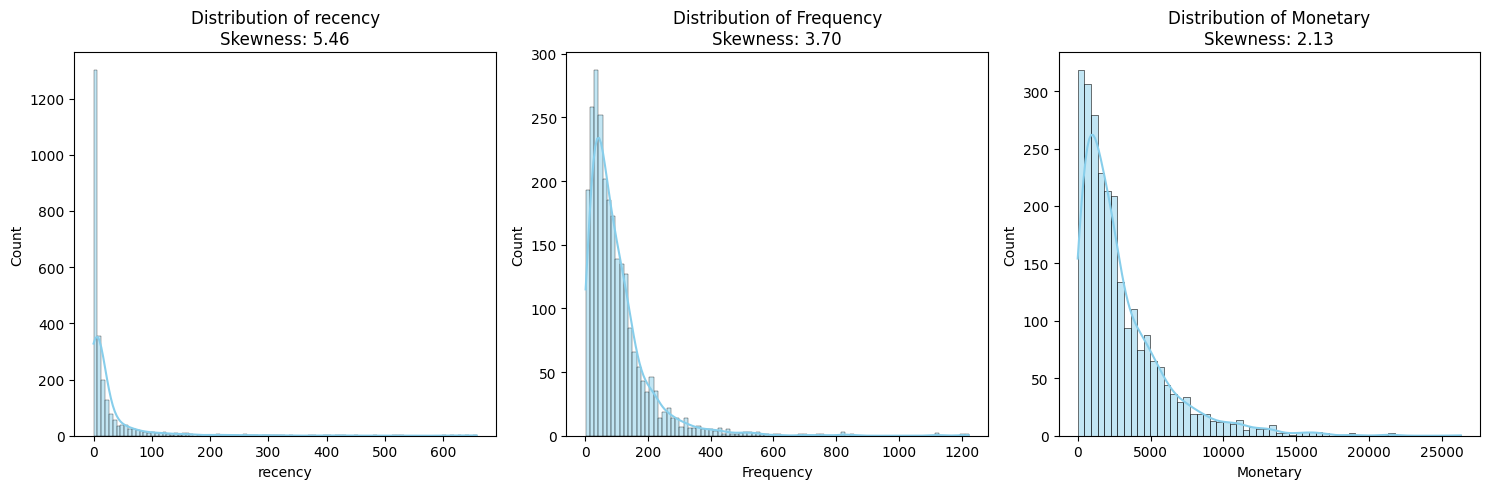

In [8]:
features = ['recency', 'Frequency', 'Monetary']
plt.figure(figsize=(15, 5))

for i, feature in enumerate(features):
    plt.subplot(1, 3, i+1)
    sns.histplot(customer_base_rfm[feature], kde=True, color='skyblue')
    plt.title(f'Distribution of {feature}\nSkewness: {customer_base_rfm[feature].skew():.2f}')

plt.tight_layout()
plt.show()


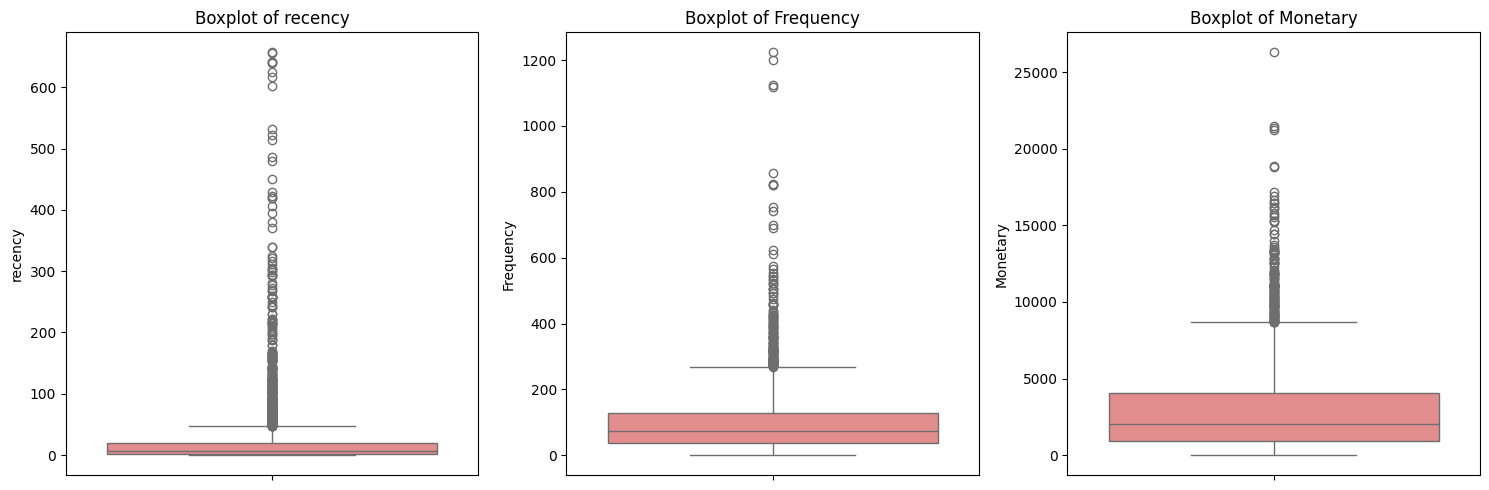

In [9]:
plt.figure(figsize=(15, 5))
for i, feature in enumerate(features):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=customer_base_rfm[feature], color='lightcoral')
    plt.title(f'Boxplot of {feature}')

plt.tight_layout()
plt.show()


## Step 2: Preprocessing Pipeline

Applied Yeo-Johnson Power Transformation to handle high skewness and outliers.
This step includes Z-score standardization (mean=0, std=1) to satisfy 
K-Means assumptions and prevent features with larger scales from dominating the model.

In [10]:
rfm_features = ['recency', 'Frequency', 'Monetary']
X = customer_base_rfm[rfm_features]

In [11]:
# Initialize PowerTransformer
# Yeo-johnson handles skewness and standardize=True scales to N(0,1)
scaler = PowerTransformer(method='yeo-johnson', standardize=True)

# Fit and transform the data
rfm_scaled = scaler.fit_transform(X)

# Create a DataFrame for scaled data
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=rfm_features, index=customer_base_rfm.index)

print("Data transformed and standardized successfully.")
rfm_scaled_df.head()

Data transformed and standardized successfully.


,recency,Frequency,Monetary
0,-0.118165,0.171843,0.777343
1,0.863262,-1.827696,-1.625367
2,0.713297,-1.077611,-0.021625
3,-0.118165,0.671287,0.688504
4,-0.977349,0.259491,0.715836


## Step 3: Determining Optimal Number of Clusters (K)
Using Elbow Method (Inertia) and Silhouette Score to find the best K.

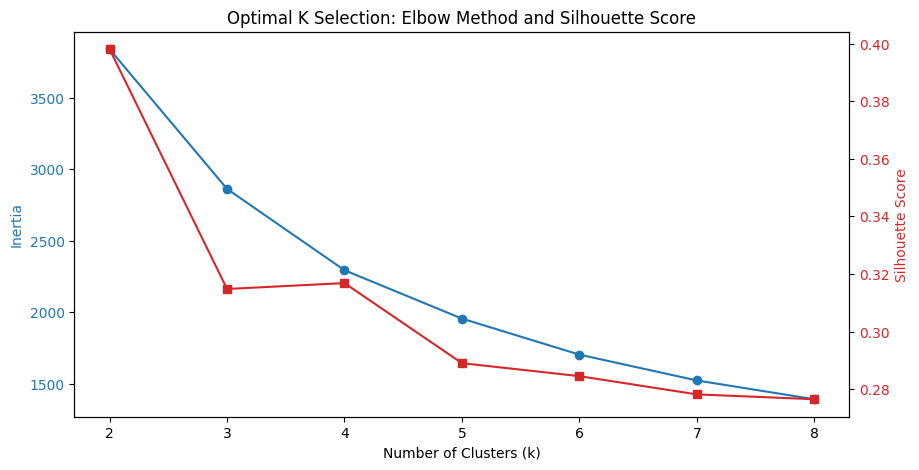

In [12]:
inertia = []
silhouette_vals = []
k_range = range(2, 9)

for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_vals.append(silhouette_score(rfm_scaled, kmeans.labels_))

# Plotting Elbow and Silhouette Score
fig, ax1 = plt.subplots(figsize=(10, 5))

# Elbow Curve
ax1.plot(k_range, inertia, color='tab:blue', marker='o', label='Inertia (Elbow)')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Silhouette Score
ax2 = ax1.twinx()
ax2.plot(k_range, silhouette_vals, color='tab:red', marker='s', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Optimal K Selection: Elbow Method and Silhouette Score')
plt.show()

In [13]:
# Fit K-Means with optimal K
optimal_k = 4 
kmeans_final = KMeans(n_clusters=optimal_k, n_init=10, random_state=42)
customer_base_rfm['cluster'] = kmeans_final.fit_predict(rfm_scaled)


In [14]:
customer_base_rfm.head()

,household_key,recency,Frequency,Monetary,is_churn,cluster
0,1,5,83,4310.160156,0,3
1,10,26,9,234.339996,0,2
2,100,20,23,1959.219971,0,3
3,1000,5,130,3972.439941,0,0
4,1001,1,90,4074.020020,0,0


## Step 4: Cluster Profiling & Analysis
Analyzing the characteristics of each cluster and merging with demographics.

--- Cluster Summary Profile ---


,cluster,recency,Frequency,Monetary,churn_rate,customer_count
0,0,2.632801,210.329463,6381.768555,0.037736,689
1,1,1.704545,65.336777,1576.220093,0.000000,484
2,2,81.740351,22.759649,539.751648,0.221053,570
3,3,22.248349,81.388375,2543.823242,0.198151,757


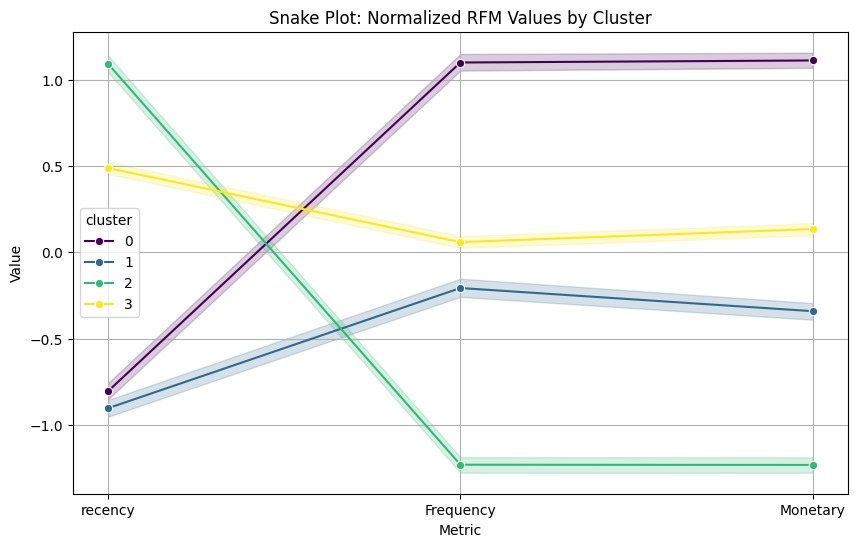

In [15]:
# 1. Calculate Mean RFM and Churn Rate per cluster using original values
cluster_profile = customer_base_rfm.groupby('cluster').agg({
    'recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'is_churn': 'mean',
    'household_key': 'count'
}).rename(columns={'is_churn': 'churn_rate', 'household_key': 'customer_count'}).reset_index()

# 2. Merge with Demographics for deeper insights
# Ensure 'household_key' exists in both
customer_clusters = customer_base_rfm[['household_key', 'cluster']].merge(demographics, on='household_key', how='left')

print("--- Cluster Summary Profile ---")
display(cluster_profile)

# 3. Visualizing Cluster Characteristics (Snake Plot)
rfm_scaled_df['cluster'] = customer_base_rfm['cluster']
df_melt = pd.melt(rfm_scaled_df.reset_index(), id_vars=['cluster'], value_vars=rfm_features, 
                  var_name='Metric', value_name='Value')

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_melt, x='Metric', y='Value', hue='cluster', palette='viridis', marker='o')
plt.title('Snake Plot: Normalized RFM Values by Cluster')
plt.grid(True)
plt.show()

In [ ]:
# cluster_map = {
#     0: 'Champions',
#     1: 'Potential Loyalists',
#     2: 'Hibernating',
#     3: 'At Risk'
# }
# customer_base['cluster_name'] = customer_base['cluster'].map(cluster_map)

### visualization

#### raw data

In [21]:
import plotly.express as px

# 1. Prepare data for visualization
# We use the original RFM data for real-world interpretation
plot_df = customer_base_rfm.copy()

# Sample the data if it's too large (Dunnhumby has thousands of rows)
# 10,000 is usually the sweet spot for Plotly performance
df_sample = plot_df.sample(min(10000, len(plot_df)), random_state=42)

# 2. Plot 2D View (Showing Frequency vs Monetary as it's usually the most insightful)
fig_2d = px.scatter(
    df_sample,
    x="Frequency",
    y="Monetary",
    color="cluster",
    title=f"<b>2D Cluster Projection: Frequency vs Monetary</b>",
    labels={"Frequency": "Frequency", "Monetary": "Monetary"},
    hover_data=["household_key", "recency", "Frequency", "Monetary"],
    opacity=0.7,
    color_discrete_sequence=px.colors.qualitative.Bold,
)
fig_2d.update_layout(template="plotly_white", height=700)
fig_2d.show()

# 3. Plot 3D View (Interactive RFM Space)
fig_3d = px.scatter_3d(
    df_sample,
    x="recency",      # Axis X
    y="Frequency",    # Axis Y
    z="Monetary",     # Axis Z
    color="cluster",
    title="<b>3D RFM Cluster Projection</b><br><sup>Direct mapping: X=Recency, Y=Frequency, Z=Monetary</sup>",
    labels={
        "recency": "Recency",
        "Frequency": "Frequency",
        "Monetary": "Monetary"
    },
    hover_data=["household_key", "recency", "Frequency", "Monetary"],
    opacity=0.8,
    size_max=3,
)

# Improve 3D layout aesthetics
fig_3d.update_layout(
    margin=dict(l=0, r=0, b=0, t=50),
    template="plotly_white",
    height=800,
    scene=dict(
        xaxis_title='Recency',
        yaxis_title='Frequency',
        zaxis_title='Monetary'
    )
)
fig_3d.show()

In [ ]:
# Tạo dataframe mới bằng cách gộp cột 'cluster' vào customer_base
customer_base_with_cluster = customer_base.merge(
    customer_base_rfm[['household_key', 'cluster']], 
    on='household_key', 
    how='left'
)

print("Dataframe mới 'customer_base_with_cluster' đã được tạo.")
print(f"Kích thước: {customer_base_with_cluster.shape}")
print("Các cột:", list(customer_base_with_cluster.columns))

# Hiển thị vài dòng đầu
customer_base_with_cluster.head()


#### scaled data

In [23]:
import plotly.express as px

# 1. Prepare data for visualization
# We use the scaled/transformed data to show the separation clearly
# but we can also use the original data if you prefer real-world units.
plot_df = rfm_scaled_df.copy()
plot_df['Cluster'] = customer_base_rfm['cluster'].astype(str) # Convert to string for discrete color
plot_df['household_key'] = customer_base_rfm['household_key']

# Optional: Adding original values for the hover tooltip
plot_df['Original_Recency'] = customer_base_rfm['recency']
plot_df['Original_Frequency'] = customer_base_rfm['Frequency']
plot_df['Original_Monetary'] = customer_base_rfm['Monetary']

# Sample the data if it's too large (Dunnhumby has thousands of rows)
# 10,000 is usually the sweet spot for Plotly performance
df_sample = plot_df.sample(min(10000, len(plot_df)), random_state=42)

# 2. Plot 2D View (Showing Frequency vs Monetary as it's usually the most insightful)
fig_2d = px.scatter(
    df_sample,
    x="Frequency",
    y="Monetary",
    color="Cluster",
    title=f"<b>2D Cluster Projection: Frequency vs Monetary</b>",
    labels={"Frequency": "Frequency (Standardized)", "Monetary": "Monetary (Standardized)"},
    hover_data=["household_key", "Original_Recency", "Original_Frequency", "Original_Monetary"],
    opacity=0.7,
    color_discrete_sequence=px.colors.qualitative.Bold,
)
fig_2d.update_layout(template="plotly_white", height=700)
fig_2d.show()

# 3. Plot 3D View (Interactive RFM Space)
fig_3d = px.scatter_3d(
    df_sample,
    x="recency",      # Axis X
    y="Frequency",    # Axis Y
    z="Monetary",     # Axis Z
    color="Cluster",
    title="<b>3D RFM Cluster Projection</b><br><sup>Direct mapping: X=Recency, Y=Frequency, Z=Monetary</sup>",
    labels={
        "recency": "Recency (Scaled)",
        "Frequency": "Frequency (Scaled)",
        "Monetary": "Monetary (Scaled)"
    },
    hover_data=["household_key", "Original_Recency", "Original_Frequency", "Original_Monetary"],
    opacity=0.8,
    size_max=3,
)

# Improve 3D layout aesthetics
fig_3d.update_layout(
    margin=dict(l=0, r=0, b=0, t=50),
    template="plotly_white",
    height=800,
    scene=dict(
        xaxis_title='Recency',
        yaxis_title='Frequency',
        zaxis_title='Monetary'
    )
)
fig_3d.show()